### Comprehensive Speech Feature Extraction

This script demonstrates a full audio analysis pipeline that captures speech, extracts multiple acoustic representations, and performs transcription. It visualizes four key speech features simultaneously to illustrate different perspectives on speech signals.

Key Libraries Used:

    librosa: Advanced audio feature extraction (MFCCs, Mel spectrogram)

    numpy: Signal processing and array operations

    scipy.signal: Linear spectrogram computation

    matplotlib: Feature visualization

    sounddevice: Audio recording and playback

    whisper: Speech-to-text transcription

Code Logic and Flow

The pipeline:

    Records 3 seconds of 16kHz speech

    Plays back for quality verification

    Computes and visualizes four feature representations

    Transcribes speech to text using multilingual ASR

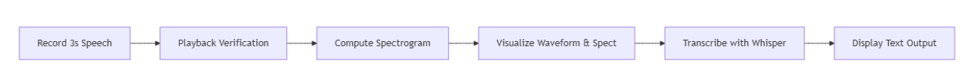

Step-by-Step Code Breakdown

1. Audio Recording & Playback

    Captures 16kHz mono audio for 3 seconds

    Immediate playback for quality control

    Uses system default input/output devices

2. Feature Extraction

    Raw Waveform:

        Time-domain amplitude visualization

        Shows energy distribution and silence periods

    Linear Spectrogram:

        Standard STFT with 256-sample windows

        Linear frequency scale (0-8kHz)

    Mel Spectrogram:

        128-band Mel-scale filterbank

        Log-scaled (dB) for perceptual relevance

        Mimics human frequency perception

    MFCCs:

        13 Mel-frequency cepstral coefficients

        Compact representation of spectral shape

3. Unified Visualization

    4-panel plot for direct comparison:

        Raw waveform (amplitude vs time)

        Linear spectrogram (frequency vs time)

        Mel spectrogram (Mel vs time)

        MFCCs (coefficients vs time)

    Saves high-resolution PNG for analysis

4. Speech Transcription

    Uses Whisper-base multilingual model

    Supports language specification (default: Hindi)

    Handles temporary file management

    Outputs cleaned transcription text

Connecting to Lecture Concepts

This implementation demonstrates:

    Perceptual Scaling: Mel scale approximates human hearing

    Feature Hierarchy: From raw signal → spectral → cepstral representations

    Dimensionality Reduction: MFCCs compress spectral information to 13 coefficients

    Phonetic Correlates: Formant visibility in Mel spectrogram

    Multilingual Capabilities: Whisper's cross-lingual performance

    Temporal Resolution: 50% window overlap maintains phoneme boundaries

    Analysis-Synthesis Gap: Features optimized for machines vs. human perception

    Speech Recognition Pipeline: Standard front-end processing for ASR

    Acoustic Landmarks: Vowel/consonant distinctions in spectrograms

    Practical Implementation: Complete workflow from capture to transcription

    Research Basis: Features used in state-of-the-art speech systems

    Perceptual Weighting: Log scaling in Mel spectrogram matches loudness perception

Recording for 3 seconds...
Playing back the recorded audio...


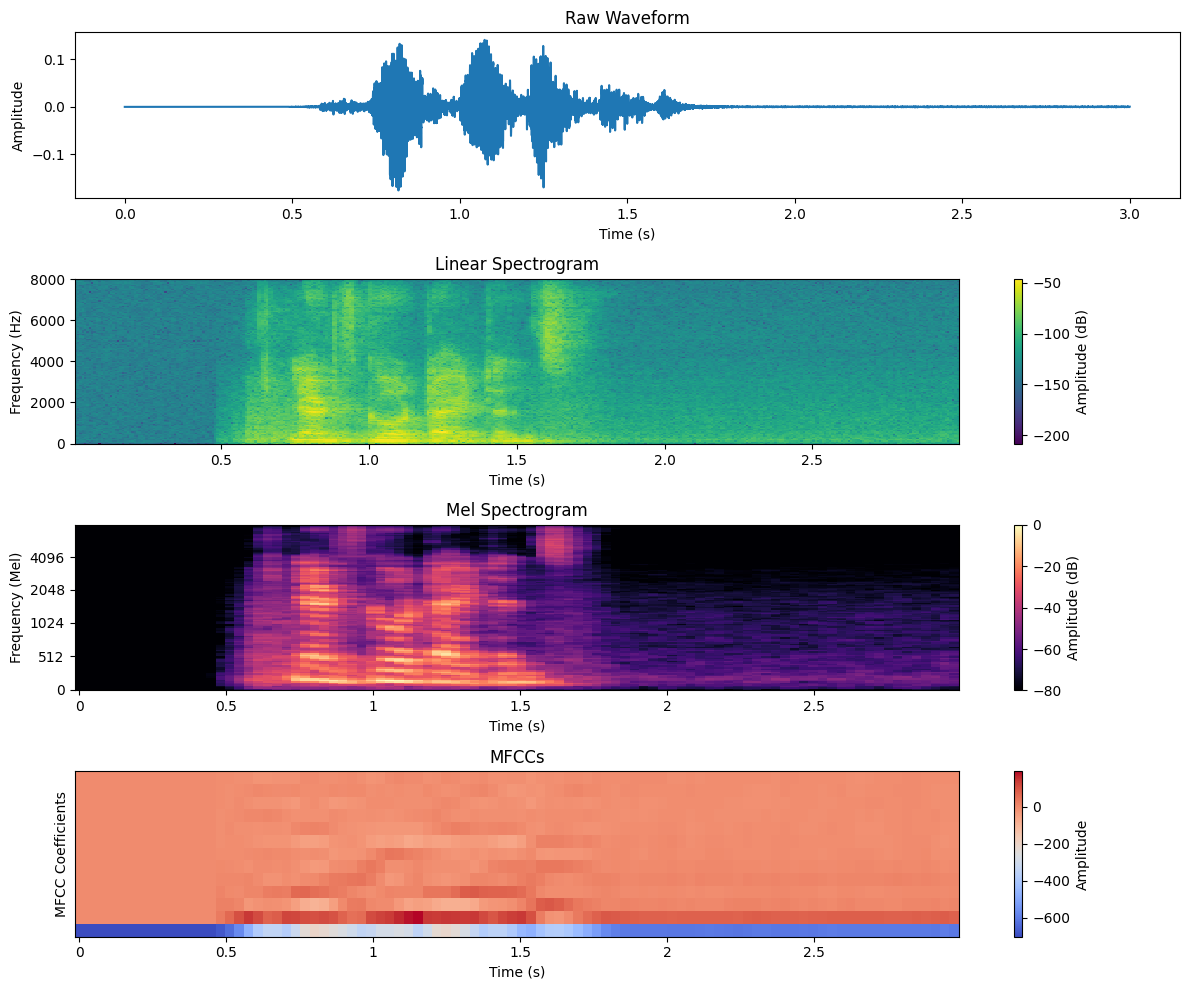

Loading Whisper model...
Transcribing audio...


C:\Users\vinit\anaconda3\envs\speechlm-rough\Lib\site-packages\whisper\transcribe.py:126: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Transcribed Text:
 let's go Titans


In [3]:
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
import whisper
import tempfile
import os

# Parameters
sample_rate = 16000  # Hz
duration = 3  # seconds

# Function to record audio
def record_audio():
    """Record audio from microphone."""
    print(f"Recording for {duration} seconds...")
    audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    sd.wait()
    audio = audio.flatten()
    return audio

# Function to play audio
def play_audio(audio, sample_rate):
    """Play back the recorded audio."""
    print("Playing back the recorded audio...")
    sd.play(audio, samplerate=sample_rate)
    sd.wait()

# Function to compute MFCCs
def compute_mfcc(audio, sample_rate):
    """Compute MFCCs using librosa."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    return mfcc

# Function to compute Mel spectrogram
def compute_mel_spectrogram(audio, sample_rate):
    """Compute Mel spectrogram using librosa."""
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
    # Convert to log scale (dB)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

# Function to plot waveform, linear spectrogram, Mel spectrogram, and MFCCs
def plot_features(audio, sample_rate):
    """Visualize raw waveform, linear spectrogram, Mel spectrogram, and MFCCs."""
    plt.figure(figsize=(12, 10))
    
    # Plot waveform
    plt.subplot(4, 1, 1)
    time = np.linspace(0, len(audio) / sample_rate, num=len(audio))
    plt.plot(time, audio)
    plt.title("Raw Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # Plot linear spectrogram
    plt.subplot(4, 1, 2)
    frequencies, times, Sxx = signal.spectrogram(audio, fs=sample_rate, nperseg=256, noverlap=128)
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='auto')
    plt.title("Linear Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Amplitude (dB)")
    
    # Plot Mel spectrogram
    plt.subplot(4, 1, 3)
    mel_spec_db = compute_mel_spectrogram(audio, sample_rate)
    librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel', sr=sample_rate, fmax=8000)
    plt.title("Mel Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Mel)")
    plt.colorbar(label="Amplitude (dB)")
    
    # Plot MFCCs
    plt.subplot(4, 1, 4)
    mfcc = compute_mfcc(audio, sample_rate)
    librosa.display.specshow(mfcc, x_axis='time', sr=sample_rate)
    plt.title("MFCCs")
    plt.xlabel("Time (s)")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar(label="Amplitude")
    
    plt.tight_layout()
    plt.savefig("audio_features_with_mel.png")
    plt.show()

# Function to transcribe audio using Whisper
def transcribe_audio(audio, sample_rate, language="hi"):
    """Transcribe the recorded audio using Whisper."""
    # Save audio to a temporary WAV file
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmpfile:
        sf.write(tmpfile.name, audio, sample_rate)
        tmpfile_path = tmpfile.name

    # Load Whisper model
    print("Loading Whisper model...")
    model = whisper.load_model("base")
    print("Transcribing audio...")
    result = model.transcribe(tmpfile_path, language=language)
    transcript = result["text"]

    # Clean up temp file
    os.remove(tmpfile_path)
    return transcript

# Main function
def main():
    # Record audio
    audio = record_audio()
    
    # Play back the recorded audio
    play_audio(audio, sample_rate)
    
    # Plot features
    plot_features(audio, sample_rate)
    
    # Transcribe and display as text
    transcript = transcribe_audio(audio, sample_rate, language="hi")  # Change to "en" for English
    print("\nTranscribed Text:")
    print(transcript)

if __name__ == "__main__":
    main()